In [3]:
#%pip install genicam
#%pip install harvesters

'''
The purpose of this script is to develop techniques for segmenting the image into crystal / not-crystal for the purpose of matting.
Ideally, this process is automatic and does not require tuning..


* This script uses the Gen<i>cam (Generic Interface for Cameras) protocol.

* The "harvesters" library builds upon the Gen<i>cam interface.
  -- details on the install here:  https://github.com/genicam/harvesters/blob/master/docs/INSTALL.rst
  -- git clone https://github.com/genicam/harvesters.git && cd harvesters && python setup.py install

* A harvester requires a GenTL producer, which generates a CTI file for your specific camera.
  - For Flir cameras, you need their "Spinnaker" SDK:
    https://www.flir.com/products/spinnaker-sdk/  
    ** https://www.edmundoptics.com/p/bfs-u3-244s8m-c-usb-31-blackflyr-s-monochrome-camera/49877/#
    ** Sony IMX540 sensor
    ** 5230 x 4600 resolution
    ** 12-bit ADC
    ** Pixel size = 2.74um
    ** Monochrome
  
  - alternative to the FLIR SDK:  https://static.matrix-vision.com/mvIMPACT_Acquire/ -- I couldn't get this to work with the FLIR camera

  - Allied Vision cameras:  https://www.alliedvision.com/en/products/vimba-sdk/#c1497
    ** https://www.edmundoptics.com/p/allied-vision-alvium-1800-u-2460m-12-246mp-c-mount-right-angle-usb-31-monochrome-camera/47015/
    ** Sony IMX540 sensor
    ** Allied Vision 1800 U-2460m
    ** pixel size:  2.74um
    ** 5328 x 4608 resolution
    ** 12-bit ADC
    ** Monochrome
  
'''

# Imports
import os
import time
import glob
import pickle
import copy

import numpy as np
import cv2 as cv
from matplotlib import pylab as plt
from camera import Camera
from zaberXRSW60AE03 import XRSWE
from math import sqrt


ctiFilePath_av1 = 'C:/Program Files/Allied Vision/Vimba_6.0/VimbaUSBTL/Bin/Win64/VimbaUSBTL.cti'
serialNumber_av1 = ''
resolution_av1 = (5328, 4608)
nBits_av1 = 8

imageScaleFactor = (1/4)
calibrationFolder = 'cal_images_color'
ArUcoMarkerSize = 10.0   # mm


#-------------------------------------------------------------------------------
#                                   show_image
#-------------------------------------------------------------------------------
def show_image(title, opencvImage):
    
    plt.figure()
    # OpenCV stores images in BGR order instead of RGB, so convert
    plt.imshow(cv.cvtColor(opencvImage, cv.COLOR_BGR2RGB))
    plt.title(title)

    return


#-------------------------------------------------------------------------------
#                                   resize_image
#-------------------------------------------------------------------------------
def resize_image(img, newResolution=(64,64)):
    width = newResolution[0]
    height = newResolution[1]
    resized = cv.resize(img.copy(), (int(width), int(height)), interpolation=cv.INTER_AREA)
    return resized
    

# Load the camera calibration

In [4]:
calibrationFile = 'Camera_Calibration_%.3f.pickle' % imageScaleFactor


# Make sure the output folder exists
if os.path.exists(calibrationFolder) == False:
    raise Exception(f"ERROR: calibration folder doesn't exist. ({calibrationFolder})")

# Make sure the calibration file exists
calibrationFilePath = os.path.join(calibrationFolder, calibrationFile)
if os.path.exists(calibrationFilePath) == False:
    raise Exception(f"ERROR: calibration file doesn't exist. ({calibrationFilePath})")

# Open the file
with open(calibrationFilePath, 'rb') as f:
    data = pickle.load(f)

# Get the calibraiton data out of the dictionary object
mtx = data['mtx']
dist = data['dist']
rvecs = data['rvecs']
tvecs = data['tvecs']
imageScaleFactor = data['imageScaleFactor']
chessboardSquareSize = data['chessboardSquareSize_mm']  # size of an individual checkerboard, in millimeters
scaling = data['scalingFactor']  # mm / pixel

print('mtx:', mtx)
print('dist:', dist)
print('scaling factor (mm/pixel):', scaling)


mtx: [[2.62666858e+03 0.00000000e+00 5.91445417e+02]
 [0.00000000e+00 2.63415508e+03 4.37618877e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
dist: [[ 1.73310630e-01 -9.55904728e+00 -2.22998637e-02 -1.10772342e-02
   1.61882658e+02]]
scaling factor (mm/pixel): 0.13340678953742596


# Capture an image

[{'access_status': 1, 'display_name': 'Allied Vision 1800 U-2460c', 'id_': 'DEV_1AB22C033F83', 'model': '1800 U-2460c', 'parent': <genicam.gentl.Interface; proxy of <Swig Object of type 'std::shared_ptr< GenTLCpp::TLInterface > *' at 0x0000022A1A2BF690> >, 'serial_number': None, 'thisown': True, 'tl_type': 'U3V', 'user_defined_name': None, 'vendor': 'Allied Vision', 'version': None}, {'access_status': 1, 'display_name': 'Allied Vision 1800 U-2460m', 'id_': 'DEV_1AB22C03994B', 'model': '1800 U-2460m', 'parent': <genicam.gentl.Interface; proxy of <Swig Object of type 'std::shared_ptr< GenTLCpp::TLInterface > *' at 0x0000022A698637E0> >, 'serial_number': None, 'thisown': True, 'tl_type': 'U3V', 'user_defined_name': None, 'vendor': 'Allied Vision', 'version': None}]
['AcquisitionAbort', 'AcquisitionArm', 'AcquisitionControl', 'AcquisitionFrameCount', 'AcquisitionFrameRate', 'AcquisitionFrameRateEnable', 'AcquisitionFrameRateMode', 'AcquisitionMode', 'AcquisitionStart', 'AcquisitionStatus',

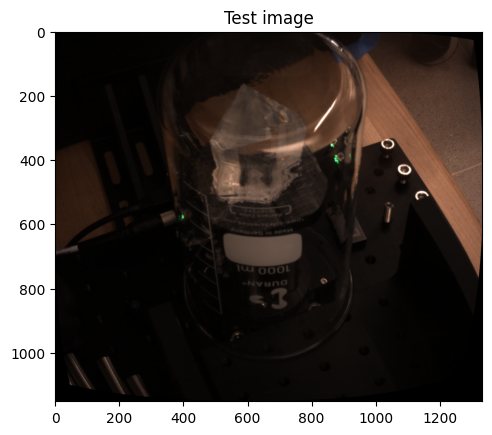

In [5]:
camera = Camera(ctiFilePath_av1, resolution_av1, nBits_av1, 'BGR', 5e6, 10.0, {'model':'1800 U-2460c'})   # color camera
#camera = Camera(ctiFilePath_av1, resolution_av1, nBits_av1, 'Mono', 5e3, 48.0, {'model':'1800 U-2460m'})    # black & white
img = camera.capture()
camera.disconnect()

small_w = resolution_av1[0] * imageScaleFactor
small_h = resolution_av1[1] * imageScaleFactor
resized = resize_image(img, (small_w, small_h))


# Undistort the image
h, w = resized.shape[:2]
newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w,h), 1, (w,h))
resized = cv.undistort(resized, mtx, dist, None, newcameramtx)

cv.imshow('img', resized)
cv.waitKey(0)
cv.destroyAllWindows()

show_image('Test image', resized)

# Find ArUco Markers

In [6]:
# Draw a 3D axis
def draw(drawImg, corners, imgpts, ArUco=True):

    # Open CV uses "BGR" instead of "RGB"
    blue = (255, 0, 0)
    green = (0, 255, 0)
    red = (0, 0, 255)

    lineThickness = 5

    print(imgpts)

    if ArUco == True:
        # Draw the R/G/B Axis Indicator
        pt1 = np.array(corners[0].ravel(), dtype=int)
        pt2a = np.array(imgpts[1].ravel(), dtype=int)
        pt2b = np.array(imgpts[3].ravel(), dtype=int)
        pt2c = np.array(imgpts[4].ravel(), dtype=int)

        drawImg = cv.line(drawImg, pt1, pt2a, blue, lineThickness)
        drawImg = cv.line(drawImg, pt1, pt2b, green, lineThickness)
        drawImg = cv.line(drawImg, pt1, pt2c, red, lineThickness)
    
    else:
        '''
        # Draw the R/G/B Axis Indicator
        pt1 = np.array(corners[0].ravel(), dtype=int)
        pt2a = np.array(imgpts[0].ravel(), dtype=int)
        pt2b = np.array(imgpts[1].ravel(), dtype=int)
        pt2c = np.array(imgpts[2].ravel(), dtype=int)

        drawImg = cv.line(drawImg, pt1, pt2a, blue, lineThickness)
        drawImg = cv.line(drawImg, pt1, pt2b, green, lineThickness)
        drawImg = cv.line(drawImg, pt1, pt2c, red, lineThickness)
        '''

        imgpts = np.int32(imgpts).reshape(-1,2)

        # draw ground floor in green
        basePoints = np.array([imgpts[:4]], dtype=int)
        drawImg = cv.drawContours(drawImg, basePoints, -1, green, -3)
        
        
        # draw pillars in blue color
        for i,j in zip(range(4),range(4,8)):
            pt1 = np.array(imgpts[i], dtype=int)
            pt2 = np.array(imgpts[j], dtype=int)
            drawImg = cv.line(drawImg, pt1, pt2, blue, lineThickness)
        
        # draw top layer in red color
        topPoints = np.array([imgpts[4:]], dtype=int)
        drawImg = cv.drawContours(drawImg, topPoints, -1, red, lineThickness)

    return drawImg

![ArUco Marker Coordinates](ArUcoCoordinates.png =25%x)

MARKER CORNER COORDINATES (relative to center of stage in mm):
[top left, top right, bottom right, bottom left]

ID0:    (-28.75, 22.25, 5) - Top Left
        (-28.75, 22.25, -5)  - Top Right
        (-28.75, 12.25, -5) - Bottom Right
        (-28.75, 12.25, 5) - Bottom Left

ID1:    (28.75, 22.25, -5) - Top Left
        (28.75, 22.25, 5)  - Top Right
        (28.75, 12.25, 5) - Bottom Right
        (28.75, 12.25, -5) - Bottom Left

ID2:    (-5, 0, -25) - Top Left
        (5, 0, -25)  - Top Right
        (5, 0, -15)  - Bottom Right
        (-5, 0, -15) - Bottom Left

ID3:    (15, 0, -5) - Top Left
        (25, 0, -5) - Top Right
        (25, 0, 5)  - Bottom Right
        (15, 0, 5)  - Bottom left

ID4:    (-5, 0, 15) - Top Left
        (5, 0, 15)  - Top Right
        (5, 0, 25)  - Bottom Right
        (-5, 0, 25) - Bottom Left

ID5:    (-25, 0, -5) - Top Left
        (-15, 0, -5) - Top Right
        (-15, 0, 5)  - Bottom Right
        (-25, 0, 5)  - Bottom Left

In [7]:
def get_marker_coordinates(id):
    '''
    This function returns the real-world coordinates for a given marker. 
    
    A list of 4 points are returned.  The points are in the following order:
    0. Top Left Coordinate
    1. Top Right Coordinate
    2. Bottom Right Coordinate
    3. Bottom Left Coordinate
    '''
    
    points = []
    if id == 0:
        topLeft = np.array([-28.75, 22.25, 5])
        topRight = np.array([-28.75, 22.25, -5])
        bottomRight = np.array([-28.75, 12.25, -5])
        bottomLeft = np.array([-28.75, 12.25, 5])

    elif id == 1:
        topLeft = np.array([28.75, 22.25, -5])
        topRight = np.array([28.75, 22.25, 5])
        bottomRight = np.array([28.75, 12.25, 5])
        bottomLeft = np.array([28.75, 12.25, -5])
    
    elif id == 2:
        topLeft = np.array([-5, 0, -25])
        topRight = np.array([5, 0, -25])
        bottomRight = np.array([5, 0, -15])
        bottomLeft = np.array([-5, 0, -15])

    elif id == 3:
        topLeft = np.array([15, 0, -5])
        topRight = np.array([25, 0, -5])
        bottomRight = np.array([25, 0, 5])
        bottomLeft = np.array([15, 0, 5])

    elif id == 4:
        topLeft = np.array([-5, 0, 15])
        topRight = np.array([5, 0, 15])
        bottomRight = np.array([5, 0, 25])
        bottomLeft = np.array([-5, 0, 25])

    elif id == 5:
        topLeft = np.array([-25, 0, -5])
        topRight = np.array([-15, 0, -5])
        bottomRight = np.array([-15, 0, 5])
        bottomLeft = np.array([-25, 0, 5])

    else:
        raise Exception(f'ERROR: specified id ({id}) not in list...')

    points.append(topLeft)
    points.append(topRight)
    points.append(bottomRight)
    points.append(bottomLeft)
    points = np.array(points, dtype=np.float32)

    return points

In [8]:
def compute_normal(points):
    v1 = points[1] - points[0]
    v2 = points[1] - points[2]
    n = np.cross(v1, v2) / (ArUcoMarkerSize**2)
    return n

def get_marker_coordinates_3d(marker_points, offsetAmount=ArUcoMarkerSize):
    ''' Get the corner coordinates and add a second set offset from the first surface... '''

    offset_points = copy.deepcopy(marker_points)

    # Compute the normal for the top-left coordinate & add it to the offset coordinates
    points = [marker_points[-1], marker_points[0], marker_points[1]]
    n = compute_normal(points) * offsetAmount
    offset_points[0] += n
    offset_points[1] += n
    offset_points[2] += n
    offset_points[3] += n
    
    marker_points_3d = np.vstack((marker_points, offset_points))

    return marker_points_3d

In [9]:
# Test the offset function...
id0 = get_marker_coordinates(1)
print(id0)
id0_3d = get_marker_coordinates_3d(id0)
print(id0_3d)

[[28.75 22.25 -5.  ]
 [28.75 22.25  5.  ]
 [28.75 12.25  5.  ]
 [28.75 12.25 -5.  ]]
[[28.75 22.25 -5.  ]
 [28.75 22.25  5.  ]
 [28.75 12.25  5.  ]
 [28.75 12.25 -5.  ]
 [18.75 22.25 -5.  ]
 [18.75 22.25  5.  ]
 [18.75 12.25  5.  ]
 [18.75 12.25 -5.  ]]


In [10]:
'''
# Load the marker
ArUcoImage = resized

# Create a grayscale version of the image
gray = cv.cvtColor(ArUcoImage, cv.COLOR_BGR2GRAY)

# Make a copy of the image too
arucoImg2 = copy.deepcopy(ArUcoImage)

# Create aruco parameters
arucoParams = cv.aruco.DetectorParameters()

# Defined above:  aruco_dict = cv.aruco.getPredefinedDictionary(cv.aruco.DICT_4X4_50)  # 4x4 bits, minimum hamming distance between any two codes = 4, 50 codes
aruco_dict = cv.aruco.getPredefinedDictionary(cv.aruco.DICT_4X4_50)  # 4x4 bits, minimum hamming distance between any two codes = 4, 50 codes

# Create an ArUco detector object
detector = cv.aruco.ArucoDetector(aruco_dict, arucoParams)

# Find the markers
(corners, ids, rejected) = detector.detectMarkers(ArUcoImage)

# Draw the markers
arucoImg2 = cv.aruco.drawDetectedMarkers(arucoImg2, corners, ids)

# OpenCV stores images in BGR order instead of RGB, so convert
#show_image('ArUco Markers', arucoImg2)


# Loop over each discovered marker
for c,id,r in zip(corners, ids, rejected):
    
    print(f'Processing ArUco ID#{id}...')
    
    marker_points = get_marker_coordinates(id)
    ret,rvecs,tvecs = cv.solvePnP(marker_points, c[0], mtx, dist, False, cv.SOLVEPNP_IPPE_SQUARE)

    # project 3D points to image plane
    offsetAmount = 10
    marker_points_offset = get_marker_coordinates_3d(marker_points, offsetAmount)
    imgpts, jac = cv.projectPoints(marker_points_offset, rvecs, tvecs, mtx, dist)

    # Draw the red/gree/blue lines indicating where the grid is
    arucoImg2 = draw(arucoImg2, c[0], imgpts, True)

    # Add the origin
    radius = 5
    color = (0,0,255) # red
    origin_pt, jac = cv.projectPoints((0,0,0), rvecs, tvecs, mtx, dist)
    origin_pt = np.array(origin_pt[0][0], dtype=int)
    arucoImg2 = cv.circle(arucoImg2, origin_pt, radius, color, -1)

    # Put boxes around where the other codes SHOULD be...
    for i in range(0, 6):
        
        #if i == id:
        if i in ids:
            continue

        lineColor = (255, 0, 0)  # blue
        lineThickness = 2

        m = get_marker_coordinates(i)
        m_projected, jac = cv.projectPoints(m, rvecs, tvecs, mtx, dist)
        m_projected = np.asarray(m_projected, dtype=np.int32)

        # Draw the first line
        pt1 = m_projected[0, :].flatten()
        pt2 = m_projected[1, :].flatten()
        arucoImg2 = cv.line(arucoImg2, pt1, pt2, lineColor, lineThickness)

        pt1 = m_projected[1, :].flatten()
        pt2 = m_projected[2, :].flatten()
        arucoImg2 = cv.line(arucoImg2, pt1, pt2, lineColor, lineThickness)

        pt1 = m_projected[2, :].flatten()
        pt2 = m_projected[3, :].flatten()
        arucoImg2 = cv.line(arucoImg2, pt1, pt2, lineColor, lineThickness)

        pt1 = m_projected[3, :].flatten()
        pt2 = m_projected[0, :].flatten()
        arucoImg2 = cv.line(arucoImg2, pt1, pt2, lineColor, lineThickness)


# Display the final image with all markers identified
show_image('ArUco Markers', arucoImg2)

cv.imshow('ArUco Markers', arucoImg2)
cv.waitKey(0)
cv.destroyAllWindows()
'''

"\n# Load the marker\nArUcoImage = resized\n\n# Create a grayscale version of the image\ngray = cv.cvtColor(ArUcoImage, cv.COLOR_BGR2GRAY)\n\n# Make a copy of the image too\narucoImg2 = copy.deepcopy(ArUcoImage)\n\n# Create aruco parameters\narucoParams = cv.aruco.DetectorParameters()\n\n# Defined above:  aruco_dict = cv.aruco.getPredefinedDictionary(cv.aruco.DICT_4X4_50)  # 4x4 bits, minimum hamming distance between any two codes = 4, 50 codes\naruco_dict = cv.aruco.getPredefinedDictionary(cv.aruco.DICT_4X4_50)  # 4x4 bits, minimum hamming distance between any two codes = 4, 50 codes\n\n# Create an ArUco detector object\ndetector = cv.aruco.ArucoDetector(aruco_dict, arucoParams)\n\n# Find the markers\n(corners, ids, rejected) = detector.detectMarkers(ArUcoImage)\n\n# Draw the markers\narucoImg2 = cv.aruco.drawDetectedMarkers(arucoImg2, corners, ids)\n\n# OpenCV stores images in BGR order instead of RGB, so convert\n#show_image('ArUco Markers', arucoImg2)\n\n\n# Loop over each discover

# Use simultaneous detection of multiple ArUco Markers

In [2]:
# Load the marker
ArUcoImage = resized

# Create a grayscale version of the image
gray = cv.cvtColor(ArUcoImage, cv.COLOR_BGR2GRAY)

# Make a copy of the image too
arucoImg2 = copy.deepcopy(ArUcoImage)

# Create aruco parameters
arucoParams = cv.aruco.DetectorParameters()

# Defined above:  aruco_dict = cv.aruco.getPredefinedDictionary(cv.aruco.DICT_4X4_50)  # 4x4 bits, minimum hamming distance between any two codes = 4, 50 codes
aruco_dict = cv.aruco.getPredefinedDictionary(cv.aruco.DICT_4X4_50)  # 4x4 bits, minimum hamming distance between any two codes = 4, 50 codes

# Create an ArUco detector object
detector = cv.aruco.ArucoDetector(aruco_dict, arucoParams)

# Find the markers
(corners, ids, rejected) = detector.detectMarkers(ArUcoImage)


###### TODO!!!!!!!
## https://answers.opencv.org/question/224823/calculate-distance-between-the-center-of-the-aruco-marker-and-the-center-of-the-camera/
## aruco.refineDetectedMarkers -- this refines the detected markers after calling the "detectMarkers" function.
## try this!



# Draw the markers
arucoImg2 = cv.aruco.drawDetectedMarkers(arucoImg2, corners, ids)

# OpenCV stores images in BGR order instead of RGB, so convert
#show_image('ArUco Markers', arucoImg2)

allCorners = None
allMarkers = None

for i in range(0, len(ids)):
    id = ids[i]
    c = corners[i].reshape((4,2))
    m = get_marker_coordinates(id)

    if allCorners is None:
        allCorners = c
    else:
        allCorners = np.vstack((allCorners, c))

    if allMarkers is None:
        allMarkers = m
    else:
        allMarkers = np.vstack((allMarkers, m))
    
ret,rvecs,tvecs = cv.solvePnP(allMarkers, allCorners, mtx, dist, False, cv.SOLVEPNP_IPPE_SQUARE)


# Add the origin
radius = 5
color = (0,0,255) # red
origin_pt, jac = cv.projectPoints((0,0,0), rvecs, tvecs, mtx, dist)
origin_pt = np.array(origin_pt[0][0], dtype=int)
arucoImg2 = cv.circle(arucoImg2, origin_pt, radius, color, -1)


# Put boxes around where the other codes SHOULD be...
for i in range(0, 6):
    
    #if i == id:
    if i in ids:
        continue

    lineColor = (255, 0, 0)  # blue
    lineThickness = 2

    m = get_marker_coordinates(i)
    m_projected, jac = cv.projectPoints(m, rvecs, tvecs, mtx, dist)
    m_projected = np.asarray(m_projected, dtype=np.int32)

    # Draw the first line
    pt1 = m_projected[0, :].flatten()
    pt2 = m_projected[1, :].flatten()
    arucoImg2 = cv.line(arucoImg2, pt1, pt2, lineColor, lineThickness)

    pt1 = m_projected[1, :].flatten()
    pt2 = m_projected[2, :].flatten()
    arucoImg2 = cv.line(arucoImg2, pt1, pt2, lineColor, lineThickness)

    pt1 = m_projected[2, :].flatten()
    pt2 = m_projected[3, :].flatten()
    arucoImg2 = cv.line(arucoImg2, pt1, pt2, lineColor, lineThickness)

    pt1 = m_projected[3, :].flatten()
    pt2 = m_projected[0, :].flatten()
    arucoImg2 = cv.line(arucoImg2, pt1, pt2, lineColor, lineThickness)



### TODO:  Estimate the pose (camera angle)
## https://docs.opencv.org/3.4/d9/d6a/group__aruco.html#ga896ca24f0c1b4b277b6e59d5fe001dd5
## Should return a rotation and translation matrix


# Display the final image with all markers identified
show_image('ArUco Markers', arucoImg2)

cv.imshow('ArUco Markers', arucoImg2)
cv.waitKey(0)
cv.destroyAllWindows()


NameError: name 'resized' is not defined

# Capture the "Crystal" from Multiple Angles

In [ ]:
captureCrystalImages = False
outputFolder = 'small_white_crystal_supports'

stepSize = 1   # Step size, in degrees


if captureCrystalImages == True:

    # Make sure the output folder exists
    if os.path.exists(outputFolder) == False:
        os.mkdir(outputFolder)

    # Connect to the zaber rotation stage
    rotationStage = XRSWE()

    # Connect to the camera
    camera = Camera(ctiFilePath_av1, resolution_av1, nBits_av1, 'Mono', 5e3, 48.0, {'model':'1800 U-2460m'})    # black & white camera

    # Increase the velocity
    rotationStage.set_velocity(30.0)  # degrees / second

    # Home the device
    rotationStage.home()
    rotationStage.move_abs(0)

    for degree in np.arange(0, 360, stepSize):
        print(f'Capturing {degree} degrees...')

        # Move to a position
        rotationStage.move_abs(degree)
        img = camera.capture()
        cv.imwrite('./%s/crystal_%04d.jpg' % (outputFolder, degree), img)

        #show_image(f'{degree} degrees', img)

    # Disconnect from the camera
    camera.disconnect()

    # Disconnect from the rotation stage
    rotationStage.disconnect()